# **Predicting Near-Earth Objects' Potential Hazardous Impact**

**Project Type:** Data Analysis

**Course:** DSC 478 – Programming Machine Learning Applications

**Team Members:** Brian Urban, Marcin Tylman, Venkata Sairohith Maddineni, Ragasree Krishnan

<br>

### **Overview**

This project aims to use machine learning tools to analyze and predict the potentially hazardous impact of near-Earth objects (NEOs) or asteroids based on the neo.csv dataset. The analysis will focus on identifying patterns in asteroid characteristics and assessing potential hazards. The study will use data mining techniques such as clustering and classification to derive insights into asteroid properties and their potential risks.

<br>

### **Analysis Approach**

##### **DM Task 1: Pre-processing**

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load dataset
neo_data = pd.read_csv('neo.csv')

# Display dataset info
neo_data.info()
print("\nFirst Five Rows of NEO Dataset:\n", neo_data.head())


def preprocess_data(neo_data):
    # Columns
    numerical_features = ['est_diameter_min', 'est_diameter_max', 
                          'relative_velocity', 'miss_distance', 
                          'absolute_magnitude']
    
    categorical_feature = 'orbiting_body'
    boolean_features = ['hazardous']

    # Impute numerical features with median
    num_imputer = SimpleImputer(strategy='median')
    neo_data[numerical_features] = num_imputer.fit_transform(neo_data[numerical_features])
    
    # Impute categorical with constant value
    neo_data[categorical_feature] = neo_data[categorical_feature].fillna('Unknown')
    
    # Impute boolean features with False
    for col in boolean_features:
        neo_data[col] = neo_data[col].fillna(False)
        neo_data[col] = neo_data[col].astype(int)

    # Scale numerical features
    scaler = StandardScaler()
    neo_data[numerical_features] = pd.DataFrame(scaler.fit_transform(neo_data[numerical_features]),
                                                columns=numerical_features)

    # One-hot encode orbiting_body
    neo_data = pd.get_dummies(neo_data, columns=[categorical_feature], drop_first=True)

    # Drop non-essential columns
    neo_data.drop(columns=['id', 'name', 'sentry_object'], inplace=True)

    return neo_data


# Preprocess dataset
processed_neo_data = preprocess_data(neo_data)

# Display processed dataset info
print("\nProcessed Data Sample:\n", processed_neo_data.head())
print(f"\nDataset shape: {processed_neo_data.shape}")
print(f"Number of hazardous objects: {processed_neo_data['hazardous'].sum()}")
print(f"Percentage of hazardous objects: {processed_neo_data['hazardous'].mean()*100:.2f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB

First Five Rows of NEO Dataset:
         id                 name  est_diameter_min  est_diameter_max  \
0  2162635  162635 (2000 SS164)          1.198271          2.679415   
1  2277475    277475 (2005 WK4)          0.265800       

<br>

##### **DM Task 2: Exploratory Phase**

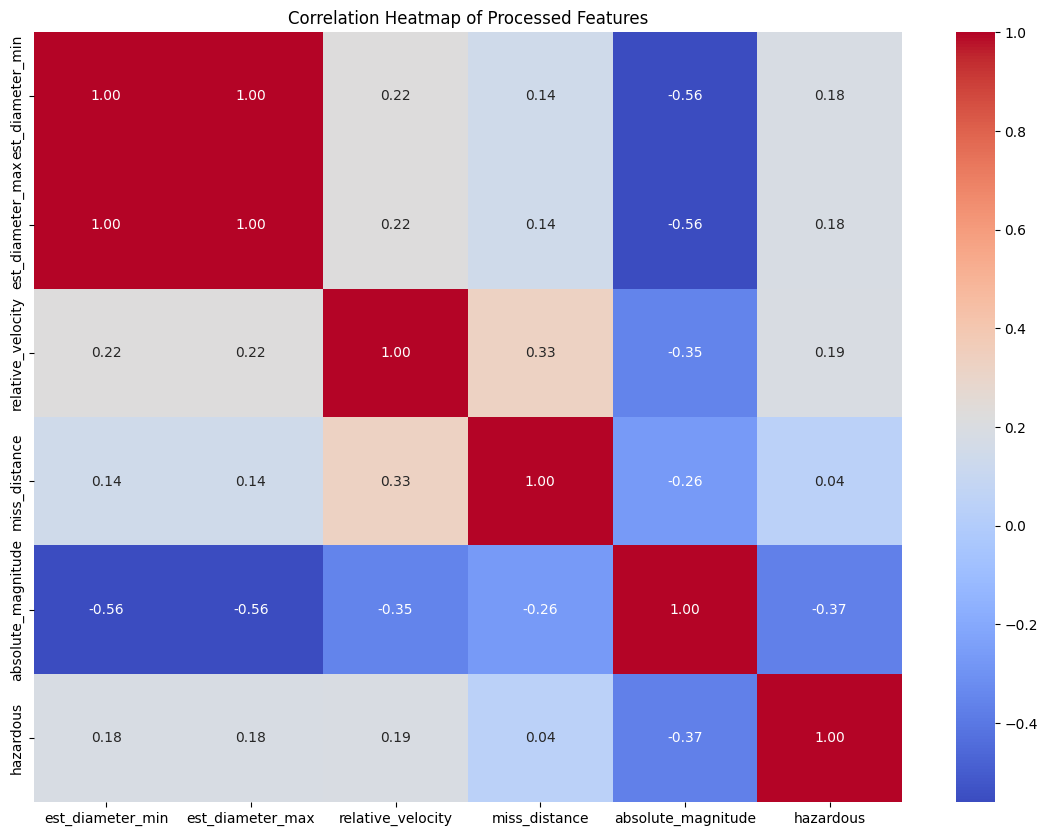

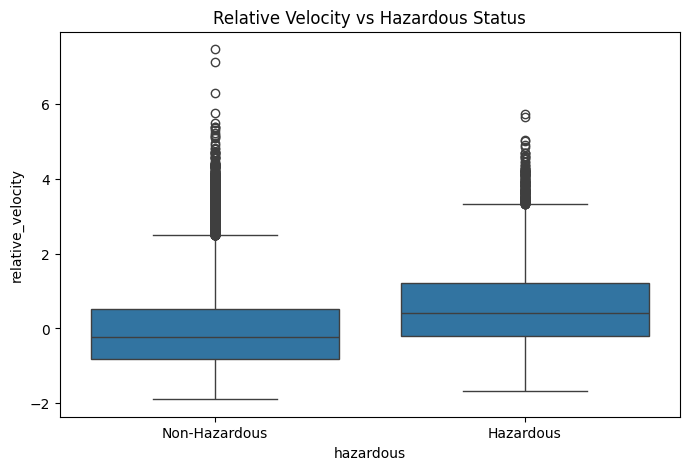

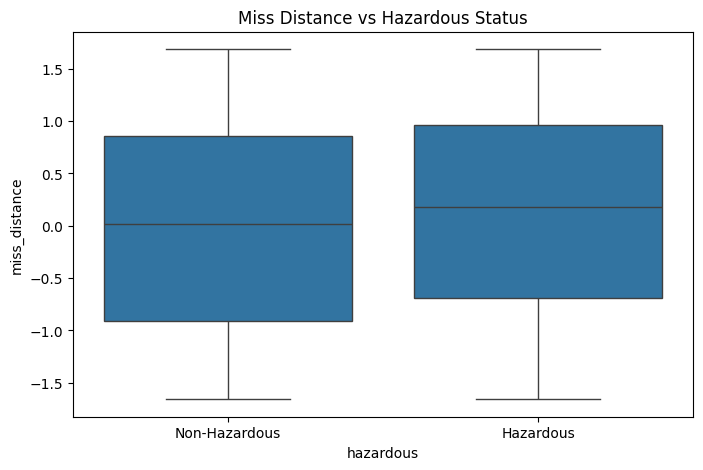

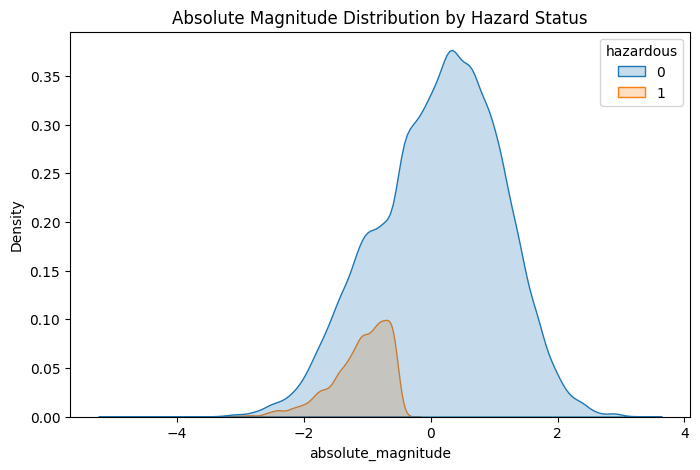

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(processed_neo_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Processed Features")
plt.show()

# Boxplot: Relative Velocity vs Hazardous
plt.figure(figsize=(8, 5))
sns.boxplot(x='hazardous', y='relative_velocity', data=processed_neo_data)
plt.title("Relative Velocity vs Hazardous Status")
plt.xticks([0,1], ['Non-Hazardous', 'Hazardous'])
plt.show()

# Boxplot: Miss Distance vs Hazardous
plt.figure(figsize=(8, 5))
sns.boxplot(x='hazardous', y='miss_distance', data=processed_neo_data)
plt.title("Miss Distance vs Hazardous Status")
plt.xticks([0,1], ['Non-Hazardous', 'Hazardous'])
plt.show()

# KDE Plot: Absolute Magnitude Distribution by Hazard Status
plt.figure(figsize=(8, 5))
sns.kdeplot(data=processed_neo_data, x='absolute_magnitude', hue='hazardous', fill=True)
plt.title("Absolute Magnitude Distribution by Hazard Status")
plt.show()

<br>

##### **DM Task 3: Supervised Learning**

Class Distribution:
 hazardous
0    0.902682
1    0.097318
Name: proportion, dtype: float64

Logistic Regression Performance:
Accuracy: 0.7821
Precision: 0.2949
Recall: 0.9271
F1-Score: 0.4475
ROC-AUC: 0.8470

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.77      0.86     16439
           1       0.29      0.93      0.45      1729

    accuracy                           0.78     18168
   macro avg       0.64      0.85      0.66     18168
weighted avg       0.92      0.78      0.82     18168



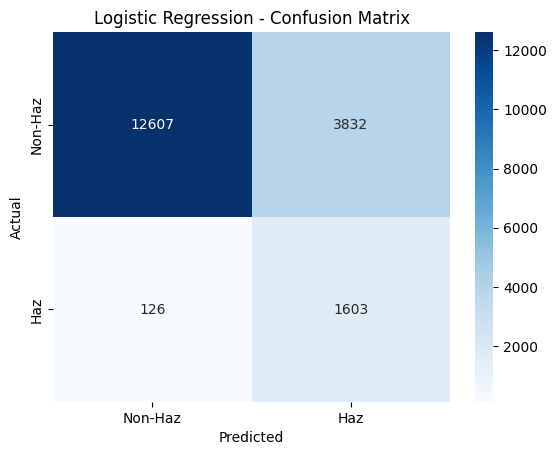


Random Forest Performance:
Accuracy: 0.9205
Precision: 0.6264
Recall: 0.4083
F1-Score: 0.4944
ROC-AUC: 0.6914

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96     16439
           1       0.63      0.41      0.49      1729

    accuracy                           0.92     18168
   macro avg       0.78      0.69      0.73     18168
weighted avg       0.91      0.92      0.91     18168



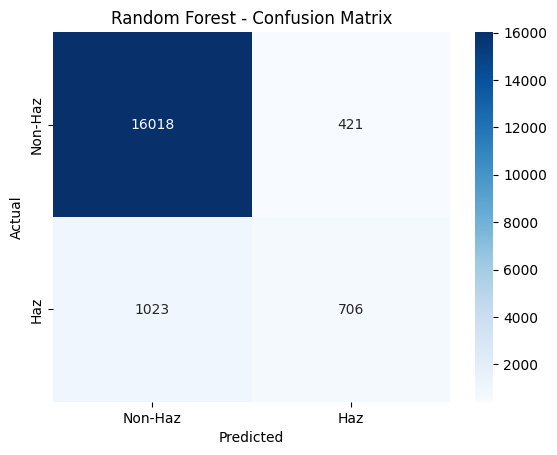


Gradient Boosting Performance:
Accuracy: 0.9144
Precision: 0.7806
Recall: 0.1400
F1-Score: 0.2374
ROC-AUC: 0.5679

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.95     16439
           1       0.78      0.14      0.24      1729

    accuracy                           0.91     18168
   macro avg       0.85      0.57      0.60     18168
weighted avg       0.90      0.91      0.89     18168



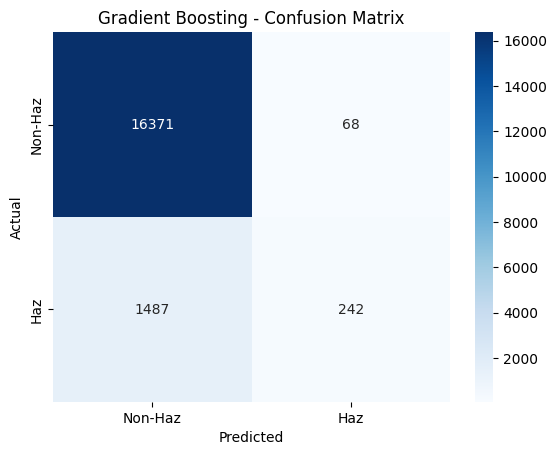

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix, 
                             roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt

# Train-test split
X = processed_neo_data.drop(columns=['hazardous'])
y = processed_neo_data['hazardous']

# Check class balance
print("Class Distribution:\n", y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models with class_weight='balanced' for class imbalance (LogReg, RF)
log_reg = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')
gb_clf = GradientBoostingClassifier(random_state=42)  # No class_weight, but still effective

# Train models
log_reg.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)

# Predict
log_reg_pred = log_reg.predict(X_test)
rf_clf_pred = rf_clf.predict(X_test)
gb_clf_pred = gb_clf.predict(X_test)

# Evaluation function
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Haz', 'Haz'], yticklabels=['Non-Haz', 'Haz'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluate all models
evaluate_model("Logistic Regression", y_test, log_reg_pred)
evaluate_model("Random Forest", y_test, rf_clf_pred)
evaluate_model("Gradient Boosting", y_test, gb_clf_pred)

<br>

### **Conclusion**

In this project, we aimed to predict whether a Near-Earth Object (NEO) is potentially hazardous using a combination of data preprocessing, exploratory analysis, and supervised learning models.

**Key Findings from Preprocessing & Exploration:**

* **Data Cleaning:** Handled missing values effectively and standardized numerical features for consistent model input.

* **Exploratory Analysis** revealed that:
    
    * Hazardous objects tend to have lower miss distances and brighter absolute magnitudes.
    
    * There is a slight trend of higher relative velocities among hazardous objects.
    
    * These insights guided the feature importance expectations in modeling.

**Model Performance Summary:**

* Logistic Regression achieved the highest recall (0.93), making it ideal for identifying as many hazardous objects as possible—critical in real-world safety scenarios.

* Random Forest delivered higher precision (0.63) with balanced performance, better suited where false positives are costly.

* Gradient Boosting had high precision but poor recall, underperforming in detecting hazardous objects.

**Recommendations:**

* For safety-critical applications, prioritize Logistic Regression to minimize false negatives (missed hazardous NEOs).

* For balanced performance, use Random Forest, especially when resource constraints require minimizing false alerts.

* Further model tuning (e.g., hyperparameter optimization) and ensemble methods could enhance prediction reliability.